## Step 1: Import the libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


## Step 2: Create a messy dataset

We create a small student dataset that contains missing values, duplicate rows and outliers.

In [2]:
data = {
    "StudentID": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 5],
    "Name":      ["Amit", "Riya", "Karan", "Neha", "Raj", "Simran", "Dev", "Anjali",
                  "Rohan", "Pooja", "Kiran", "Raj"],
    "Age":       [20, 21, np.nan, 20, 22, 21, 20, np.nan, 21, 20, 22, 22],
    "Marks":     [78, 85, 90, np.nan, 66, 74, 250, 88, 79, -40, 82, 66],
    "City":      ["Surat", "Vadodara", "Surat", "Rajkot", None, "Surat", "Ahmedabad",
                  "Rajkot", "Surat", "Vadodara", "Ahmedabad", None],
}

df = pd.DataFrame(data)
print("Original dataset:")
df

Original dataset:


,StudentID,Name,Age,Marks,City
0,1,Amit,20.0,78.0,Surat
1,2,Riya,21.0,85.0,Vadodara
2,3,Karan,NaN,90.0,Surat
3,4,Neha,20.0,NaN,Rajkot
4,5,Raj,22.0,66.0,NaN
5,6,Simran,21.0,74.0,Surat
6,7,Dev,20.0,250.0,Ahmedabad
7,8,Anjali,NaN,88.0,Rajkot
8,9,Rohan,21.0,79.0,Surat
9,10,Pooja,20.0,-40.0,Vadodara


## Step 3: Understand the data

In [3]:
print("Shape (rows, columns):", df.shape)
print("\nData types and non-null counts:")
df.info()

Shape (rows, columns): (12, 5)

Data types and non-null counts:
<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   StudentID  12 non-null     int64  
 1   Name       12 non-null     str    
 2   Age        10 non-null     float64
 3   Marks      11 non-null     float64
 4   City       10 non-null     str    
dtypes: float64(2), int64(1), str(2)
memory usage: 612.0 bytes


In [4]:
print("Statistical summary:")
df.describe()

Statistical summary:


,StudentID,Age,Marks
count,12.000000,10.000000,11.000000
mean,5.916667,20.900000,83.454545
std,3.175426,0.875595,66.177585
min,1.000000,20.000000,-40.000000
25%,3.750000,20.000000,70.000000
50%,5.500000,21.000000,79.000000
75%,8.250000,21.750000,86.500000
max,11.000000,22.000000,250.000000


## Part A: Detect and handle MISSING values

In [5]:
# Step 4: Count missing values in each column
print("Missing values per column:")
print(df.isnull().sum())

print("\nTotal missing values:", df.isnull().sum().sum())

Missing values per column:
StudentID    0
Name         0
Age          2
Marks        1
City         2
dtype: int64

Total missing values: 5


In [6]:
# Step 5: Show rows that contain missing values
df[df.isnull().any(axis=1)]

,StudentID,Name,Age,Marks,City
2,3,Karan,NaN,90.0,Surat
3,4,Neha,20.0,NaN,Rajkot
4,5,Raj,22.0,66.0,NaN
7,8,Anjali,NaN,88.0,Rajkot
11,5,Raj,22.0,66.0,NaN


In [7]:
# Step 6: Handle missing values
# We work on a copy so that the original stays safe
df_clean = df.copy()

# Numeric columns -> fill with median (median is not affected by outliers)
df_clean["Age"] = df_clean["Age"].fillna(df_clean["Age"].median())
df_clean["Marks"] = df_clean["Marks"].fillna(df_clean["Marks"].median())

# Text column -> fill with the most frequent value (mode)
df_clean["City"] = df_clean["City"].fillna(df_clean["City"].mode()[0])

print("Missing values after cleaning:")
print(df_clean.isnull().sum())
df_clean

Missing values after cleaning:
StudentID    0
Name         0
Age          0
Marks        0
City         0
dtype: int64


,StudentID,Name,Age,Marks,City
0,1,Amit,20.0,78.0,Surat
1,2,Riya,21.0,85.0,Vadodara
2,3,Karan,21.0,90.0,Surat
3,4,Neha,20.0,79.0,Rajkot
4,5,Raj,22.0,66.0,Surat
5,6,Simran,21.0,74.0,Surat
6,7,Dev,20.0,250.0,Ahmedabad
7,8,Anjali,21.0,88.0,Rajkot
8,9,Rohan,21.0,79.0,Surat
9,10,Pooja,20.0,-40.0,Vadodara


**Other option:** `df.dropna()` removes every row that has a missing value. We prefer filling here so we do not lose data.

## Part B: Detect and remove DUPLICATE records

> **Why do this after filling missing values?** Look at StudentID 5 (Raj). His two rows look the same, but if we had checked before filling, `City` was `NaN` in both. Cleaning missing values first makes it easier to spot true duplicates. The order of cleaning steps matters!

In [8]:
# Step 7: Find duplicates
print("Number of duplicate rows:", df_clean.duplicated().sum())

print("\nDuplicate rows:")
df_clean[df_clean.duplicated(keep=False)]

Number of duplicate rows: 1

Duplicate rows:


,StudentID,Name,Age,Marks,City
4,5,Raj,22.0,66.0,Surat
11,5,Raj,22.0,66.0,Surat


In [9]:
# Step 8: Remove duplicates (keep the first occurrence)
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
after = len(df_clean)

print(f"Rows before: {before}   Rows after: {after}   Removed: {before - after}")
df_clean

Rows before: 12   Rows after: 11   Removed: 1


,StudentID,Name,Age,Marks,City
0,1,Amit,20.0,78.0,Surat
1,2,Riya,21.0,85.0,Vadodara
2,3,Karan,21.0,90.0,Surat
3,4,Neha,20.0,79.0,Rajkot
4,5,Raj,22.0,66.0,Surat
5,6,Simran,21.0,74.0,Surat
6,7,Dev,20.0,250.0,Ahmedabad
7,8,Anjali,21.0,88.0,Rajkot
8,9,Rohan,21.0,79.0,Surat
9,10,Pooja,20.0,-40.0,Vadodara


## Part C: Detect and treat OUTLIERS

Look at the `Marks` column: values like **250** and **-40** are impossible for marks out of 100.

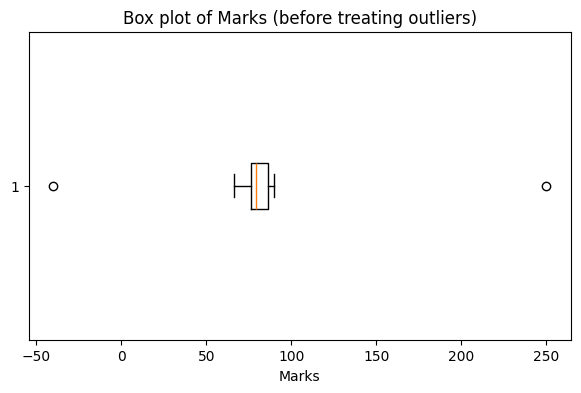

In [10]:
# Step 9: Visualize outliers using a box plot
plt.figure(figsize=(7, 4))
plt.boxplot(df_clean["Marks"], vert=False)
plt.title("Box plot of Marks (before treating outliers)")
plt.xlabel("Marks")
plt.show()

In [11]:
# Step 10: Detect outliers using the IQR method
Q1 = df_clean["Marks"].quantile(0.25)
Q3 = df_clean["Marks"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1 =", Q1)
print("Q3 =", Q3)
print("IQR =", IQR)
print("Lower bound =", lower_bound)
print("Upper bound =", upper_bound)

outliers = df_clean[(df_clean["Marks"] < lower_bound) | (df_clean["Marks"] > upper_bound)]
print("\nOutliers found:")
outliers

Q1 = 76.0
Q3 = 86.5
IQR = 10.5
Lower bound = 60.25
Upper bound = 102.25

Outliers found:


,StudentID,Name,Age,Marks,City
6,7,Dev,20.0,250.0,Ahmedabad
9,10,Pooja,20.0,-40.0,Vadodara


In [12]:
# Step 11: Treat outliers
# Method 1 -> REMOVE the outlier rows
df_removed = df_clean[(df_clean["Marks"] >= lower_bound) & (df_clean["Marks"] <= upper_bound)]
print("Method 1 (Remove outliers): rows left =", len(df_removed))

# Method 2 -> CAP (clip) the values to the bounds
df_capped = df_clean.copy()
df_capped["Marks"] = df_capped["Marks"].clip(lower=lower_bound, upper=upper_bound)
print("Method 2 (Cap outliers)   : rows left =", len(df_capped))

print("\nDataset after removing outliers:")
df_removed

Method 1 (Remove outliers): rows left = 9
Method 2 (Cap outliers)   : rows left = 11

Dataset after removing outliers:


,StudentID,Name,Age,Marks,City
0,1,Amit,20.0,78.0,Surat
1,2,Riya,21.0,85.0,Vadodara
2,3,Karan,21.0,90.0,Surat
3,4,Neha,20.0,79.0,Rajkot
4,5,Raj,22.0,66.0,Surat
5,6,Simran,21.0,74.0,Surat
7,8,Anjali,21.0,88.0,Rajkot
8,9,Rohan,21.0,79.0,Surat
10,11,Kiran,22.0,82.0,Ahmedabad


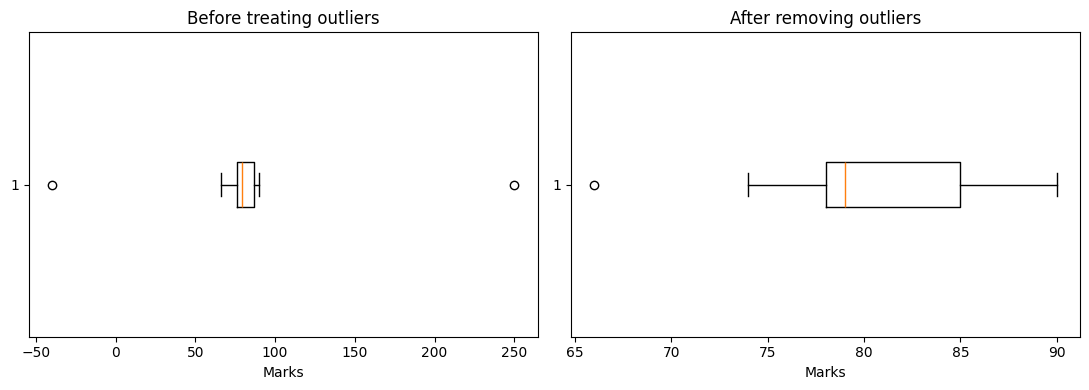

In [13]:
# Step 12: Compare before and after using box plots
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].boxplot(df_clean["Marks"], vert=False)
axes[0].set_title("Before treating outliers")

axes[1].boxplot(df_removed["Marks"], vert=False)
axes[1].set_title("After removing outliers")

for ax in axes:
    ax.set_xlabel("Marks")
plt.tight_layout()
plt.show()

## Step 13: Final cleaned dataset

In [14]:
final_df = df_removed.reset_index(drop=True)     # reset index to 0,1,2...
print("Final cleaned dataset:")
print("Shape:", final_df.shape)
print("Missing values:", final_df.isnull().sum().sum())
print("Duplicates    :", final_df.duplicated().sum())
final_df

Final cleaned dataset:
Shape: (9, 5)
Missing values: 0
Duplicates    : 0


,StudentID,Name,Age,Marks,City
0,1,Amit,20.0,78.0,Surat
1,2,Riya,21.0,85.0,Vadodara
2,3,Karan,21.0,90.0,Surat
3,4,Neha,20.0,79.0,Rajkot
4,5,Raj,22.0,66.0,Surat
5,6,Simran,21.0,74.0,Surat
6,8,Anjali,21.0,88.0,Rajkot
7,9,Rohan,21.0,79.0,Surat
8,11,Kiran,22.0,82.0,Ahmedabad


## Conclusion

- **Missing values** were detected with `isnull().sum()` and filled with median (numbers) and mode (text).
- **Duplicate records** were detected with `duplicated()` and removed with `drop_duplicates()`.
- **Outliers** were detected using the IQR method and treated by removal (and by capping).
- The final dataset has no missing values, no duplicates and no unrealistic marks, so it is ready for analysis.